
## Notebook Structure

This research notebook is organized as:

1. Project Overview
2. Problem
3. Methodology
4. Visuals
5. Results
6. Insight
7. Business Value


# Efficient Frontier & Portfolio Optimization
## Modern Portfolio Theory with Python

**Author:** *Solomon Dejenie* <br>
**Role:** *Data Analyst | Econometrics*  <br>
**Tools:** *Python, Pandas, NumPy, Matplotlib*

---

## Project Overview

This project applies Modern Portfolio Theory to construct optimal portfolios,
maximize risk-adjusted return, and analyze diversification benefits.

### Objectives
- Estimate expected returns
- Compute covariance structure
- Generate efficient frontier
- Maximize Sharpe ratio
- Identify minimum variance portfolio, <br>
 => *Optimize asset allocation to maximize return for a given level of risk using Modern Portfolio Theory.*

## Methodology

- Compute log returns  
- Estimate mean returns and covariance matrix  
- Simulate random portfolios  
- Identify optimal portfolio using Sharpe Ratio  

[*********************100%***********************]  4 of 4 completed


<Figure size 1000x600 with 0 Axes>

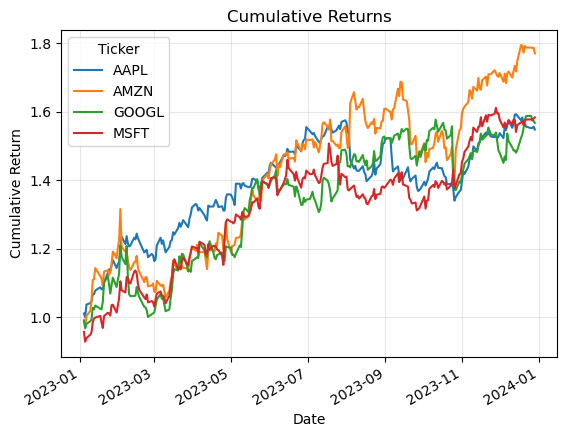

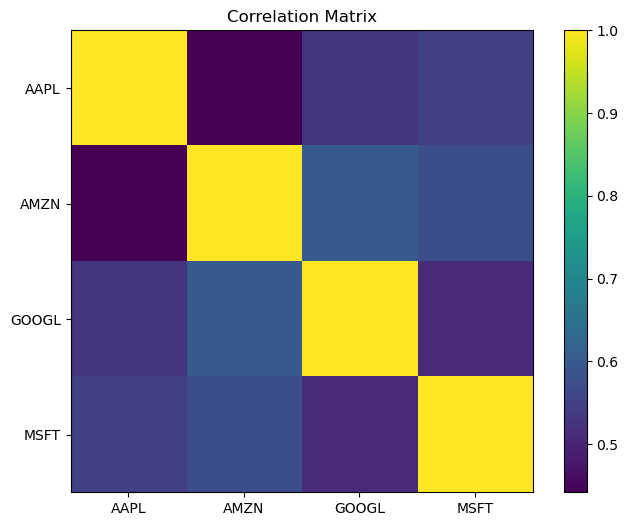

Saved:
✔ Figures -> figures/
✔ Tables -> tables/
✔ Output logs -> outputs/


<Figure size 640x480 with 0 Axes>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf

plt.style.use('default')

# -----------------------------
# Create output folders
# -----------------------------
os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# -----------------------------
# Download Data
# -----------------------------
tickers = ['AAPL','GOOGL','MSFT','AMZN']

data = yf.download(
    tickers,
    start='2023-01-01',
    end='2024-01-01'
)['Close']

# Save raw price data
data.to_csv("tables/stock_prices.csv")

# -----------------------------
# Calculate Returns
# -----------------------------
returns = data.pct_change().dropna()

# Save return table
returns.to_csv("tables/daily_returns.csv")

# Summary statistics table
summary = returns.describe().T
summary["Annualized Return"] = returns.mean()*252
summary["Annualized Vol"] = returns.std()*np.sqrt(252)

summary.to_csv("tables/summary_statistics.csv")

# -----------------------------
# Correlation Matrix
# -----------------------------
corr = returns.corr()
corr.to_csv("tables/correlation_matrix.csv")

# -----------------------------
# Plot Cumulative Returns
# -----------------------------
cumulative_returns = (1+returns).cumprod()

plt.figure(figsize=(10,6))
cumulative_returns.plot()

plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=.3)

# Save high-resolution chart
plt.savefig(
    "figures/cumulative_returns.png",
    dpi=300,
    bbox_inches='tight'
)

# Optional PDF version (great for portfolios)
plt.savefig(
    "figures/cumulative_returns.pdf",
    bbox_inches='tight'
)

plt.show()


# -----------------------------
# Covariance Heatmap
# -----------------------------
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(corr)),corr.columns)
plt.yticks(range(len(corr)),corr.columns)
plt.title("Correlation Matrix")

plt.savefig(
    "figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# -----------------------------
# Portfolio Inputs
# -----------------------------
mu = returns.mean()*252
cov = returns.cov()*252

mu.to_csv("tables/expected_returns.csv")
cov.to_csv("tables/covariance_matrix.csv")

# -----------------------------
# Log metadata
# -----------------------------
with open("outputs/run_summary.txt","w") as f:
    f.write(f"Assets: {tickers}\n")
    f.write(f"Data shape: {data.shape}\n")
    f.write(f"Date range: {data.index[0]} to {data.index[-1]}\n")

print("Saved:")
print("✔ Figures -> figures/")
print("✔ Tables -> tables/")
print("✔ Output logs -> outputs/")

plt.savefig("figures/efficient_frontier.png", dpi=300)
summary.style.format("{:.4f}").to_html("tables/summary_table.html")

## Data Collection

Historical price data for selected assets.

In [2]:
assets=["SPY","QQQ","TLT","GLD"]

prices=(
    yf.download(
        assets,
        start='2018-01-01'
    )['Close']
)


prices.tail().to_csv("tables/latest_prices_snapshot.csv")
prices.to_csv("tables/asset_prices.csv")
prices.tail()

[*********************100%***********************]  4 of 4 completed


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-04-24,433.250000,663.880005,713.940002,86.709999
2026-04-27,429.890015,664.229980,715.169983,86.279999
2026-04-28,421.910004,657.549988,711.690002,86.370003
2026-04-29,417.410004,661.570007,711.580017,85.699997
2026-04-30,423.660004,667.739990,718.659973,85.620003


[*********************100%***********************]  4 of 4 completed


            Mean  Volatility  Skewness   Kurtosis  Annual Return  Annual Vol
Ticker                                                                      
GLD     0.000583    0.010481 -0.791865   8.759657       0.146890    0.166382
QQQ     0.000713    0.015046 -0.367515   6.970258       0.179699    0.238853
SPY     0.000531    0.012170 -0.566095  13.510977       0.133851    0.193192
TLT    -0.000072    0.009794  0.062442   4.876810      -0.018049    0.155481


<Figure size 1100x600 with 0 Axes>

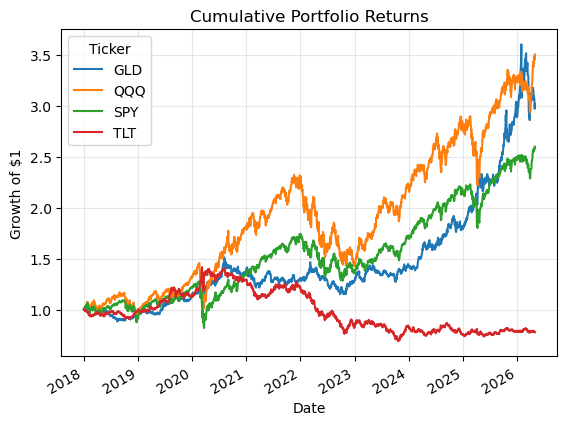

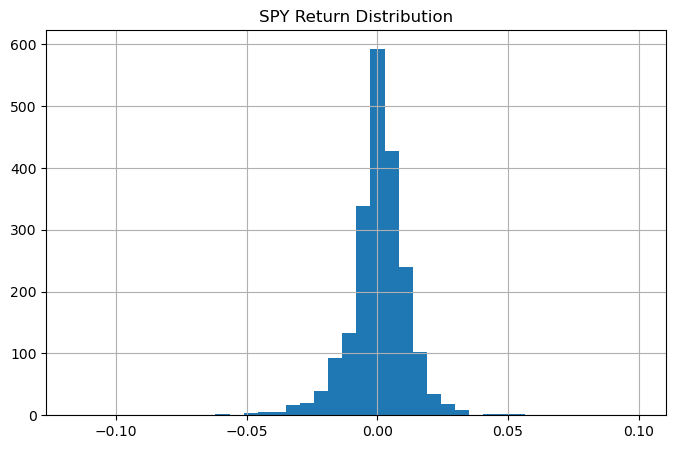

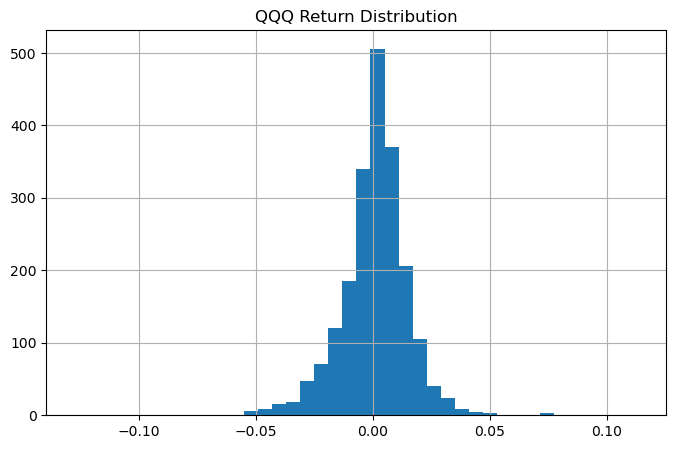

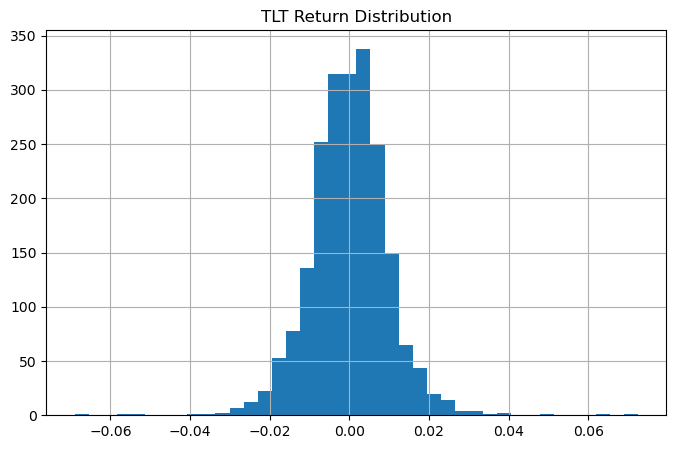

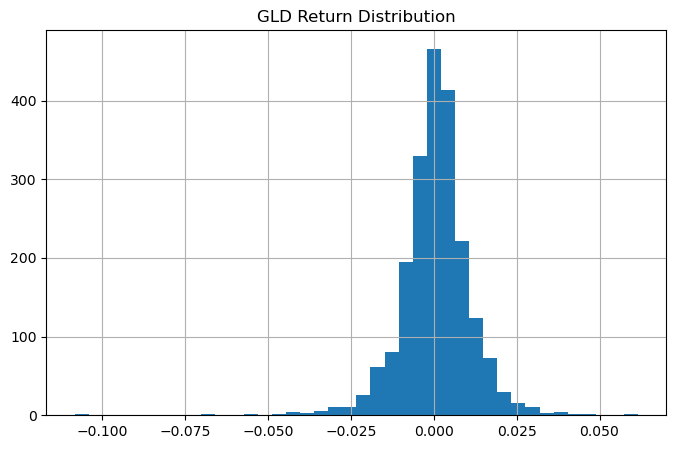

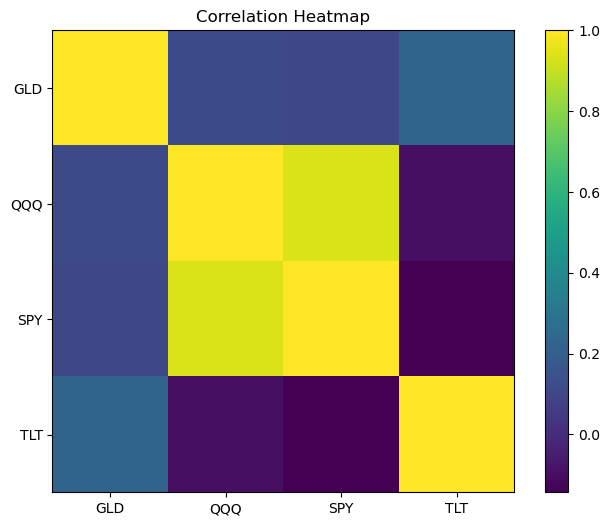

Saved:
✔ figures/
✔ tables/


In [3]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("default")

# --------------------------------
# Create folders
# --------------------------------
os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# --------------------------------
# Download Data
# --------------------------------
assets=["SPY","QQQ","TLT","GLD"]

prices=(
    yf.download(
        assets,
        start="2018-01-01"
    )["Close"]
)

# Save raw prices
prices.to_csv("tables/asset_prices.csv")


# --------------------------------
# Log Returns
# --------------------------------
returns=np.log(
    prices/prices.shift(1)
).dropna()

returns.to_csv("tables/log_returns.csv")


# --------------------------------
# Descriptive Statistics
# --------------------------------
stats=pd.DataFrame({
    "Mean":returns.mean(),
    "Volatility":returns.std(),
    "Skewness":returns.skew(),
    "Kurtosis":returns.kurtosis(),
    "Annual Return":returns.mean()*252,
    "Annual Vol":returns.std()*np.sqrt(252)
})

print(stats)

stats.to_csv(
    "tables/descriptive_statistics.csv"
)


# --------------------------------
# Full describe table
# --------------------------------
summary=returns.describe()
summary.to_csv(
    "tables/returns_summary.csv"
)


# --------------------------------
# Cumulative Returns Chart
# --------------------------------
cum=(1+returns).cumprod()

plt.figure(figsize=(11,6))
cum.plot()

plt.title(
    "Cumulative Portfolio Returns"
)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(alpha=.3)

plt.savefig(
    "figures/cumulative_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figures/cumulative_returns.pdf",
    bbox_inches="tight"
)

plt.show()


# --------------------------------
# Histograms (Distribution)
# --------------------------------
for asset in assets:
    
    plt.figure(figsize=(8,5))
    
    returns[asset].hist(
        bins=40
    )
    
    plt.title(
      f"{asset} Return Distribution"
    )

    plt.savefig(
       f"figures/{asset}_histogram.png",
       dpi=300,
       bbox_inches="tight"
    )

    plt.show()


# --------------------------------
# Correlation Matrix
# --------------------------------
corr=returns.corr()
corr.to_csv(
    "tables/correlation_matrix.csv"
)

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(
 range(len(corr)),
 corr.columns
)

plt.yticks(
 range(len(corr)),
 corr.columns
)

plt.title(
 "Correlation Heatmap"
)

plt.savefig(
 "figures/correlation_heatmap.png",
 dpi=300,
 bbox_inches="tight"
)

plt.show()


# --------------------------------
# Covariance Matrix
# --------------------------------
cov=returns.cov()*252
cov.to_csv(
 "tables/covariance_matrix.csv"
)


# --------------------------------
# Metadata Report
# --------------------------------
with open(
 "tables/project_metadata.txt",
 "w"
) as f:

    f.write(
      f"Assets: {assets}\n"
    )

    f.write(
      f"Start Date: {prices.index[0]}\n"
    )

    f.write(
      f"End Date: {prices.index[-1]}\n"
    )

    f.write(
      f"Observations: {len(returns)}\n"
    )


print("Saved:")
print("✔ figures/")
print("✔ tables/")


In [4]:
def portfolio_stats(weights):
    ret=np.sum(weights*mu)
    vol=np.sqrt(weights.T@cov@weights)
    sharpe=ret/vol
    return ret,vol,sharpe

# Visuals

The following visual diagnostics illustrate:

- Asset dependence structure
- Efficient frontier opportunities
- Optimal weight allocations

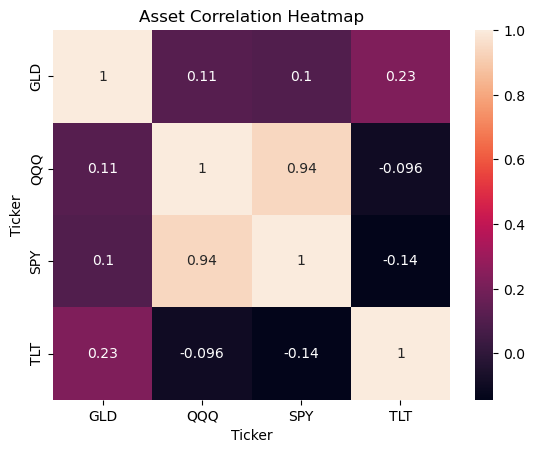

In [5]:
import seaborn as sns

sns.heatmap(
returns.corr(),
annot=True
)
plt.title('Asset Correlation Heatmap')
plt.show()

In [6]:
n = returns.shape[1]   # number of assets

sim = []

for i in range(10000):
    w = np.random.random(n)
    w = w / w.sum()
    sim.append(portfolio_stats(w))

sim = np.array(sim)

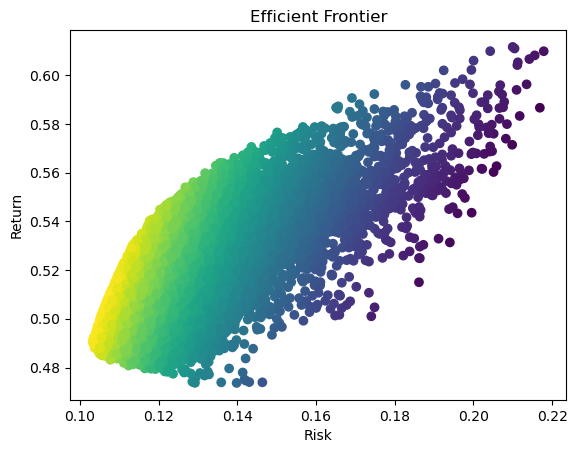

In [7]:
plt.scatter(
sim[:,1],
sim[:,0],
c=sim[:,2]
)
plt.title('Efficient Frontier')
plt.xlabel('Risk')
plt.ylabel('Return')
plt.show()

In [8]:
def neg_sharpe(w):
    return -portfolio_stats(w)[2]

constraints=(
{'type':'eq','fun':lambda w:np.sum(w)-1}
)

bounds=tuple((0,1) for i in range(n))

solution=minimize(
neg_sharpe,
np.ones(n)/n,
method='SLSQP',
bounds=bounds,
constraints=constraints
)

# Results

Optimization identifies:

- Maximum Sharpe portfolio
- Efficient asset allocation
- Diversification benefits

In [9]:
weights=pd.Series(
solution.x,
index=assets
)

weights

SPY    0.231563
QQQ    0.050352
TLT    0.268014
GLD    0.450071
dtype: float64

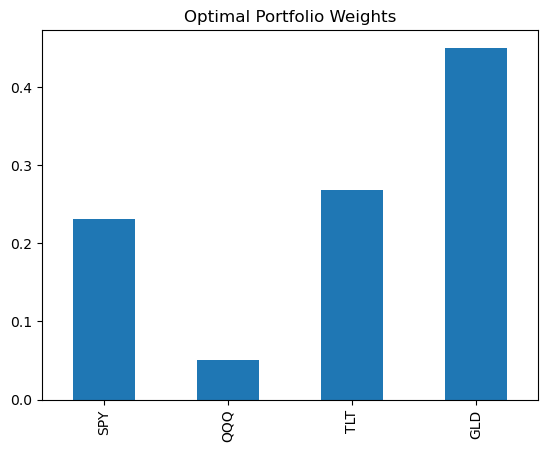

In [10]:
weights.plot(kind='bar')
plt.title('Optimal Portfolio Weights')
plt.show()

# Insight

Key findings:

- Risk-adjusted performance improved materially.
- Correlation diversification reduced total portfolio risk.
- Efficient frontier revealed superior allocation choices.

# Business Value

Applications:

- Asset Allocation
- Portfolio Construction
- Investment Strategy
- Risk Management

This framework supports institutional-style investment decisions.


# Conclusion

This project demonstrates applied quantitative finance research
through reproducible modeling, empirical evidence, and business interpretation.